# Music composition

## Exercise 1: next step
Implement this simple algorithm:
* starts with midinote = 60 and duration = 1
* increase midinote at each step
    * until it is equal to 84
* decrease midinote at each step
    * until it is equal to 60
* and so on ...

In [ ]:
import sys
import time

from classes import Agent, Composition, ID_START

class Simple_Next(Composition):
    def __init__(self, BPM = 120):
        Composition.__init__(self, BPM = BPM)
            
    def next(self):
        pass

        # lesson
        if self.id == ID_START:
            self.midinote = 60
            self.dur = 1
            self.amp = 1
            self.BPM = 120
            self.id = 0
        elif self.id == 0:
            self.midinote += 1
            if self.midinote == 84:
                self.id = 1
            else:
                self.midinote -= 1
                if self.midinote == 60:
                    self.id = 0
        # end lesson

if __name__ == "__main__":
    n_agents = 1
    composer = Simple_Next()
    agents = [_ for _ in range(n_agents)]
    agents[0] = Agent(57120, "/note_effect", composer)

    input("Press any key to start \n")
    for agent in agents:
        agent.start()
    try:                    # USE CTRL+C to exit     
        while True:
            time.sleep(10)
    except:         
        for agent in agents:              
            agent.kill()
            agent.join()
        sys.exit()


## Exercise 2: gingerbread
* two variable $ x(n) $ and $ y(n) $ with $ n $ is a count
    * $ x(0)=-0.1 $ and $ y(0)=0.1 $
* at each step
    * $ x(n+1)=1-y(n)+|x(n)| $
    * $ y(n+1)=x(n) $
* map $ x(n) $ and/or $ y(n) $ to duration and midinote
    * they range between -3 and 8 in this case
    * remap them into meaningful value

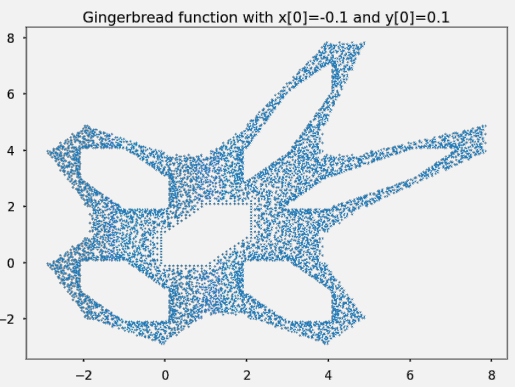

In [ ]:
import sys
import time
import numpy as np
    
from classes import Agent, Composition, ID_START

class Gingerbread(Composition):
    def __init__(self, BPM = 60):
        Composition.__init__(self, BPM = BPM)
        self.min = -3
        self.max = 8
        self.range = self.max-self.min

        # lesson
        self.x = -0.1
        self.y = 0.1
        self.amp = 1
        # end lesson

    def map(self, value_in, min_out, max_out):
        value_out = (value_in - self.min)/(self.range)
        value_out = min_out + value_out * (max_out - min_out)
        return np.clip(value_out, min_out, max_out)

    def next(self):
        # lesson
        self.amp = float(np.random.choice([0,1,1,1]))
        x_old = self.x
        self-x = 1 - self.y + abs(self.x)
        self.y = x_old
        self.midinote = int(self.map(self.y, 60, 84))
        # self.dur = self.map(self.x, 0.1, 1)
        self.dur = float(2**np.random.randint(-3, 0))
        print(self.x, self.y)
        # end lesson
    
if __name__ == "__main__":
    n_agents = 1
    composer = Gingerbread()
    agents = [_ for _ in range(n_agents)]
    agents[0] = Agent(57120, "/note_effect", composer)

    input("Press any key to start \n")
    for agent in agents:
        agent.start()
    try:                    # USE CTRL+C to exit     
        while True:
            time.sleep(10)
    except:         
        for agent in agents:              
            agent.kill()
            agent.join()
        sys.exit()